In [1]:
import sklearn
import pandas as pd
import numpy as np

# Get the Data

In [2]:
idealista = pd.read_parquet('idealista.parquet')

# Take a quick look at the data structure

In [3]:
idealista.head(3)

,ad_url,reference_id,property_type,ad_title,ad_description,transaction_type,n_rooms,n_baths,area,floor,...,country,country_code,state,city,postcode,district,quarter,price_down_from,price,viewed_at
0,https://www.idealista.com/inmueble/102834499/,102834499,vivienda,"Alquiler de Piso en calle del Amparo, Lavapiés...",UBK-493404(Disponible 1-11 meses) - Sin posibi...,alquiler,1.0,1.0,58.0,1.0,...,España,es,Comunidad de Madrid,Madrid,28012.0,Centro,Embajadores,NaN,2067.0,2024-08-01
1,https://www.idealista.com/inmueble/105893546/,105893546,viviendas,"Piso en venta en Arapiles, Chamberí, Madrid",Exclusivo piso exterior en ArapilesEngel & Völ...,buy,3.0,2.0,127.0,NaN,...,España,es,Comunidad de Madrid,Madrid,28015.0,Chamberí,Arapiles,NaN,1100000.0,2024-12-04
2,https://www.idealista.com/inmueble/103962048/,103962048,viviendas,Chalet pareado en venta en Coimbra - Guadarra...,"Se vende magnifico chalet pareado en Móstoles,...",buy,3.0,3.0,315.0,NaN,...,España,es,Comunidad de Madrid,Móstoles,28939.0,Parque Guadarrama,None,NaN,390000.0,2024-03-28


In [4]:
idealista.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 39 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ad_url                          200000 non-null  object 
 1   reference_id                    200000 non-null  int64  
 2   property_type                   200000 non-null  object 
 3   ad_title                        200000 non-null  object 
 4   ad_description                  197451 non-null  object 
 5   transaction_type                200000 non-null  object 
 6   n_rooms                         193699 non-null  float64
 7   n_baths                         196736 non-null  float64
 8   area                            198148 non-null  float64
 9   floor                           156878 non-null  float64
 10  has_elevator                    200000 non-null  bool   
 11  has_terrace                     200000 non-null  bool   
 12  is_exterior     

In [5]:
idealista['property_type'].value_counts()

property_type
vivienda      96909
viviendas     96866
garajes        2043
locales        1630
oficinas       1418
habitacion      476
terrenos        457
trasteros       129
edificios        72
Name: count, dtype: int64

In [6]:
idealista['transaction_type'].value_counts()

transaction_type
buy         73421
venta       73085
rent        26860
alquiler    26634
Name: count, dtype: int64

In [7]:
idealista['is_exterior'].value_counts()

is_exterior
True     139307
False     60124
Name: count, dtype: int64

In [8]:
idealista['energy_certificate_consumption'].value_counts()

energy_certificate_consumption
138.0    1952
300.0     823
128.0     689
80.0      688
1.0       683
         ... 
110.7       1
64.58       1
311.2       1
438.2       1
51.4        1
Name: count, Length: 2294, dtype: int64

In [9]:
idealista['energy_certificate_emissions'].value_counts()

energy_certificate_emissions
34.0     2037
1.0       695
128.0     636
300.0     632
30.0      422
         ... 
38.16       1
57.73       1
555.0       1
8.34        1
40.99       1
Name: count, Length: 1379, dtype: int64

In [10]:
idealista['energy_certificate_state'].value_counts()

energy_certificate_state
INPROCESS    68582
E            31722
UNKNOWN      30536
D            17144
A            15893
C            11944
B             6722
G             6378
F             5360
EXEMPT        2058
Name: count, dtype: int64

In [11]:
idealista['property_state'].value_counts()

property_state
Buen estado    162901
A reformar      19173
Obra nueva      13820
Name: count, dtype: int64

In [12]:
idealista['address'].value_counts()

address
Paseo de la Castellana           1388
Calle de Alcalá                  1229
Calle del Príncipe de Vergara     943
Calle de Jorge Juan               793
Calle de Goya                     775
                                 ... 
Calle de la Justicia                1
Calle de Gran Bretaña               1
Calle Oso                           1
Calle de Rosa Luxemburgo            1
Avenida de Eibar                    1
Name: count, Length: 12006, dtype: int64

In [13]:
idealista['province'].value_counts()

province
Madrid       199979
Guipúzcoa         5
Toledo            3
Ávila             2
Name: count, dtype: int64

In [14]:
idealista['country'].value_counts()

country
España    200000
Name: count, dtype: int64

In [15]:
idealista['country_code'].value_counts()

country_code
es    200000
Name: count, dtype: int64

In [16]:
idealista['state'].value_counts()

state
Comunidad de Madrid    199999
Castilla-La Mancha          1
Name: count, dtype: int64

In [17]:
idealista['city'].value_counts()

city
Madrid                   72799
madrid                   36502
MADRID                   36050
Alcobendas                3099
Getafe                    1777
                         ...  
EUROVILLAS-LAS VILLAS        1
Navacerrada                  1
GUADARRAMA                   1
PEDREZUELA                   1
VALDETORRES DE JARAMA        1
Name: count, Length: 416, dtype: int64

In [18]:
idealista['district'].value_counts()

district
Salamanca                      18900
Centro                         18185
Tetuán                         10194
Chamartín                      10088
Chamberí                        9918
                               ...  
Urbanización Dehesa Omaña          1
Ensanche                           1
Urtajo                             1
Urbanización Guadamonte            1
Urbanización Fuente del Rey        1
Name: count, Length: 316, dtype: int64

In [19]:
idealista['quarter'].value_counts()

quarter
Goya                              5289
Universidad                       4455
Recoletos                         4024
Valdefuentes                      3707
Castellana                        3630
                                  ... 
Cordel Valladolid                    1
Polígono Industrial Los Olivos       1
Oasís                                1
Carretera de Manzanares              1
Urbanización Alhambra                1
Name: count, Length: 300, dtype: int64

In [20]:
idealista['viewed_at'].value_counts()

viewed_at
2024-10-12    1413
2024-10-15    1255
2024-10-14    1227
2024-10-11     987
2024-10-10     955
              ... 
2024-01-21     207
2024-01-16     191
2024-01-15     173
2024-10-07     158
2024-10-05      87
Name: count, Length: 402, dtype: int64

In [21]:
idealista.describe(include = 'all')

,ad_url,reference_id,property_type,ad_title,ad_description,transaction_type,n_rooms,n_baths,area,floor,...,country,country_code,state,city,postcode,district,quarter,price_down_from,price,viewed_at
count,200000,2.000000e+05,200000,200000,197451,200000,193699.000000,196736.000000,198148.000000,156878.000000,...,200000,200000,200000,200000,199989.000000,180827,149834,8.342000e+03,2.000000e+05,200000
unique,98824,NaN,9,46182,90918,4,NaN,NaN,NaN,NaN,...,1,1,2,416,NaN,316,300,NaN,NaN,402
top,https://www.idealista.com/inmueble/103725340/,NaN,vivienda,"Piso en venta en Recoletos, Barrio de Salamanc...",Oportunidad de inversión: vivienda sin posesió...,buy,NaN,NaN,NaN,NaN,...,España,es,Comunidad de Madrid,Madrid,NaN,Salamanca,Goya,NaN,NaN,2024-10-12
freq,17,NaN,96909,1325,297,73421,NaN,NaN,NaN,NaN,...,200000,200000,199999,72799,NaN,18900,5289,NaN,NaN,1413
mean,NaN,1.020144e+08,NaN,NaN,NaN,NaN,2.799617,2.114219,171.726058,2.735380,...,NaN,NaN,NaN,NaN,28189.763987,NaN,NaN,5.954736e+05,5.801111e+05,NaN
std,NaN,1.218121e+07,NaN,NaN,NaN,NaN,2.808233,2.701510,2022.944165,2.537577,...,NaN,NaN,NaN,NaN,329.073437,NaN,NaN,9.151685e+05,9.647813e+05,NaN
min,NaN,1.751620e+05,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,-2.000000,...,NaN,NaN,NaN,NaN,5429.000000,NaN,NaN,2.700000e+01,2.000000e+01,NaN
25%,NaN,1.031836e+08,NaN,NaN,NaN,NaN,2.000000,1.000000,67.000000,1.000000,...,NaN,NaN,NaN,NaN,28013.000000,NaN,NaN,1.490000e+05,5.200000e+03,NaN
50%,NaN,1.046558e+08,NaN,NaN,NaN,NaN,3.000000,2.000000,99.000000,2.000000,...,NaN,NaN,NaN,NaN,28034.000000,NaN,NaN,3.066050e+05,2.695000e+05,NaN
75%,NaN,1.057048e+08,NaN,NaN,NaN,NaN,4.000000,3.000000,166.000000,4.000000,...,NaN,NaN,NaN,NaN,28220.000000,NaN,NaN,6.900000e+05,6.990000e+05,NaN


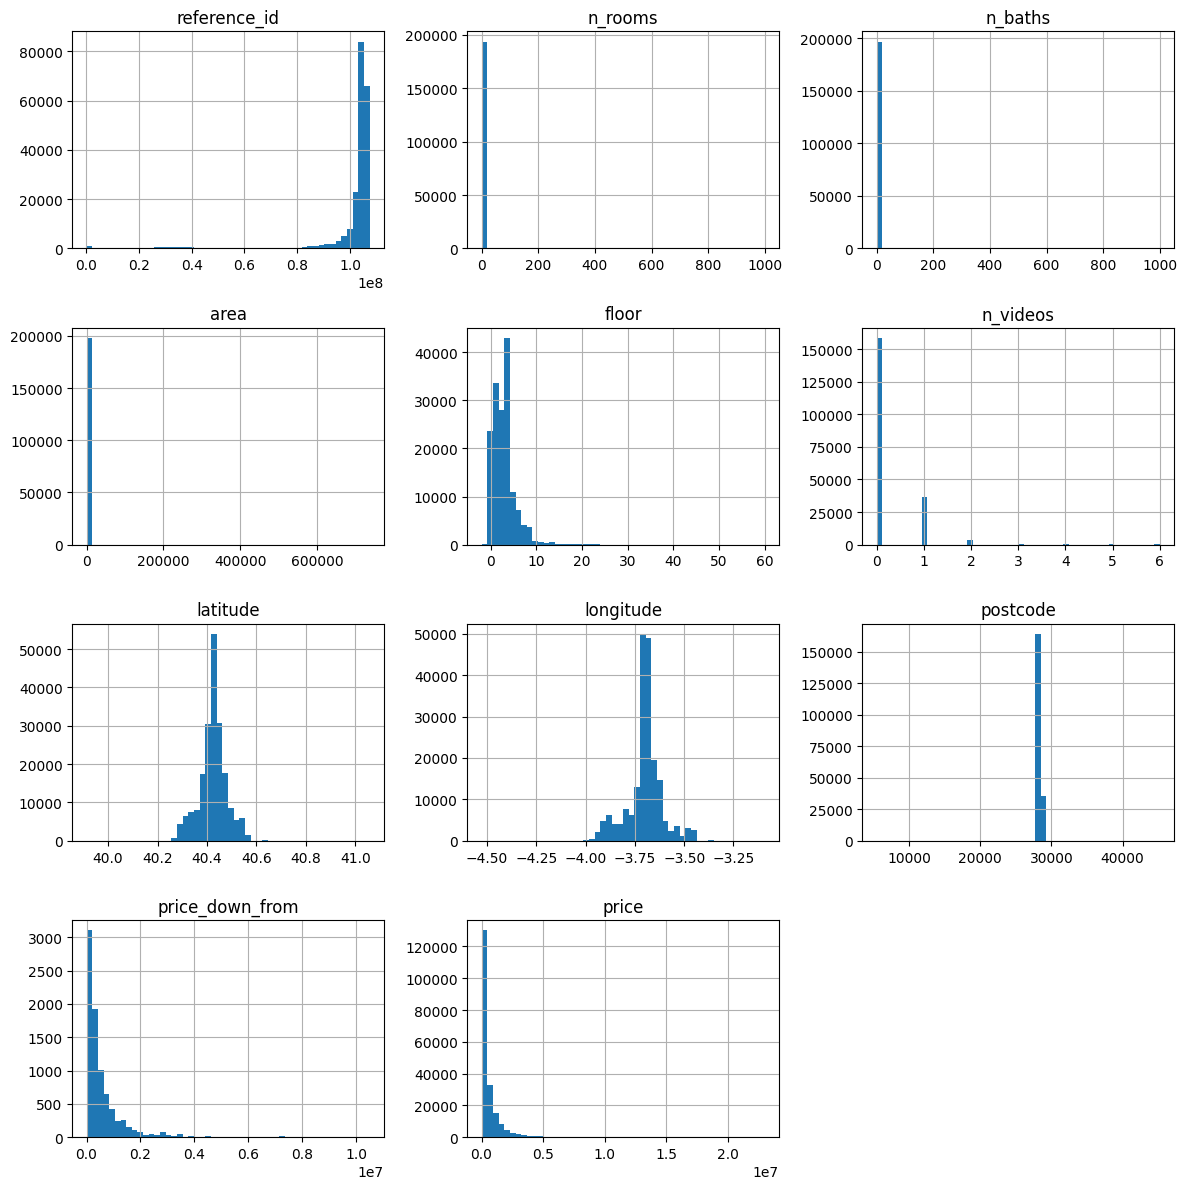

In [22]:
import matplotlib.pyplot as plt

idealista.hist(figsize=(12,12),bins = 50)
plt.tight_layout()
plt.show()

# Create Train and Test set

We will split the data into 2 set, one for rent and another for buy.

In [23]:
def transaction_type_translate(X):
  if X == 'buy':
    return 'venta'
  elif X == 'rent':
    return 'alquiler'
  else: return X

idealista['transaction_type'] = idealista['transaction_type'].apply(transaction_type_translate)
idealista['transaction_type'].value_counts()

transaction_type
venta       146506
alquiler     53494
Name: count, dtype: int64

In [24]:
idealista_rent = idealista[idealista['transaction_type'] == 'alquiler']
idealista_buy = idealista[idealista['transaction_type'] == 'venta']

In [25]:
idealista_buy.describe()

,reference_id,n_rooms,n_baths,area,floor,n_videos,latitude,longitude,postcode,price_down_from,price
count,1.465060e+05,143160.000000,144303.000000,145268.000000,111686.000000,146506.000000,146506.000000,146506.000000,146498.000000,7.011000e+03,1.465060e+05
mean,1.029169e+08,3.027508,2.254776,182.451139,2.590772,0.244871,40.422120,-3.701566,28221.500956,7.079117e+05,7.909641e+05
std,9.421554e+06,3.054027,3.043744,2325.473565,2.355991,0.554453,0.060506,0.099004,351.672361,9.577550e+05,1.050920e+06
min,1.751620e+05,0.000000,0.000000,0.000000,-2.000000,0.000000,39.912796,-4.528155,5429.000000,1.100000e+03,1.100000e+03
25%,1.032505e+08,2.000000,1.000000,72.000000,1.000000,0.000000,40.390932,-3.735025,28016.000000,2.100000e+05,2.300000e+05
50%,1.045359e+08,3.000000,2.000000,106.000000,2.000000,0.000000,40.426000,-3.694362,28037.000000,3.950000e+05,4.350000e+05
75%,1.055670e+08,4.000000,3.000000,189.000000,4.000000,0.000000,40.456466,-3.658218,28230.000000,8.000000e+05,9.300000e+05
max,1.074901e+08,999.000000,999.000000,736675.000000,60.000000,6.000000,41.058774,-3.091176,45224.000000,1.050000e+07,2.300000e+07


In [26]:
idealista_rent.describe()

,reference_id,n_rooms,n_baths,area,floor,n_videos,latitude,longitude,postcode,price_down_from,price
count,5.349400e+04,50539.000000,52433.000000,52880.000000,45192.000000,53494.00000,53494.000000,53494.000000,53491.000000,1331.000000,53494.000000
mean,9.954289e+07,2.154079,1.727385,142.262916,3.092760,0.24771,40.433287,-3.693811,28102.844647,3209.345605,2640.267226
std,1.741610e+07,1.800231,1.297262,690.827577,2.907943,0.57070,0.044665,0.064407,236.313353,9115.874451,6651.645352
min,3.604030e+05,0.000000,0.000000,0.000000,-2.000000,0.00000,40.026136,-4.441580,28000.000000,27.000000,20.000000
25%,1.023816e+08,1.000000,1.000000,56.000000,1.000000,0.00000,40.412154,-3.708407,28009.000000,1300.000000,1200.000000
50%,1.050127e+08,2.000000,1.000000,80.000000,3.000000,0.00000,40.430123,-3.694008,28020.000000,1950.000000,1650.000000
75%,1.059943e+08,3.000000,2.000000,124.000000,4.000000,0.00000,40.454862,-3.671556,28046.000000,3000.000000,2600.000000
max,1.074889e+08,250.000000,125.000000,78137.000000,60.000000,6.00000,40.854437,-3.208641,45224.000000,245000.000000,514995.000000


In [27]:
print(idealista_rent['transaction_type'].value_counts())
print(idealista_buy['transaction_type'].value_counts())

transaction_type
alquiler    53494
Name: count, dtype: int64
transaction_type
venta    146506
Name: count, dtype: int64


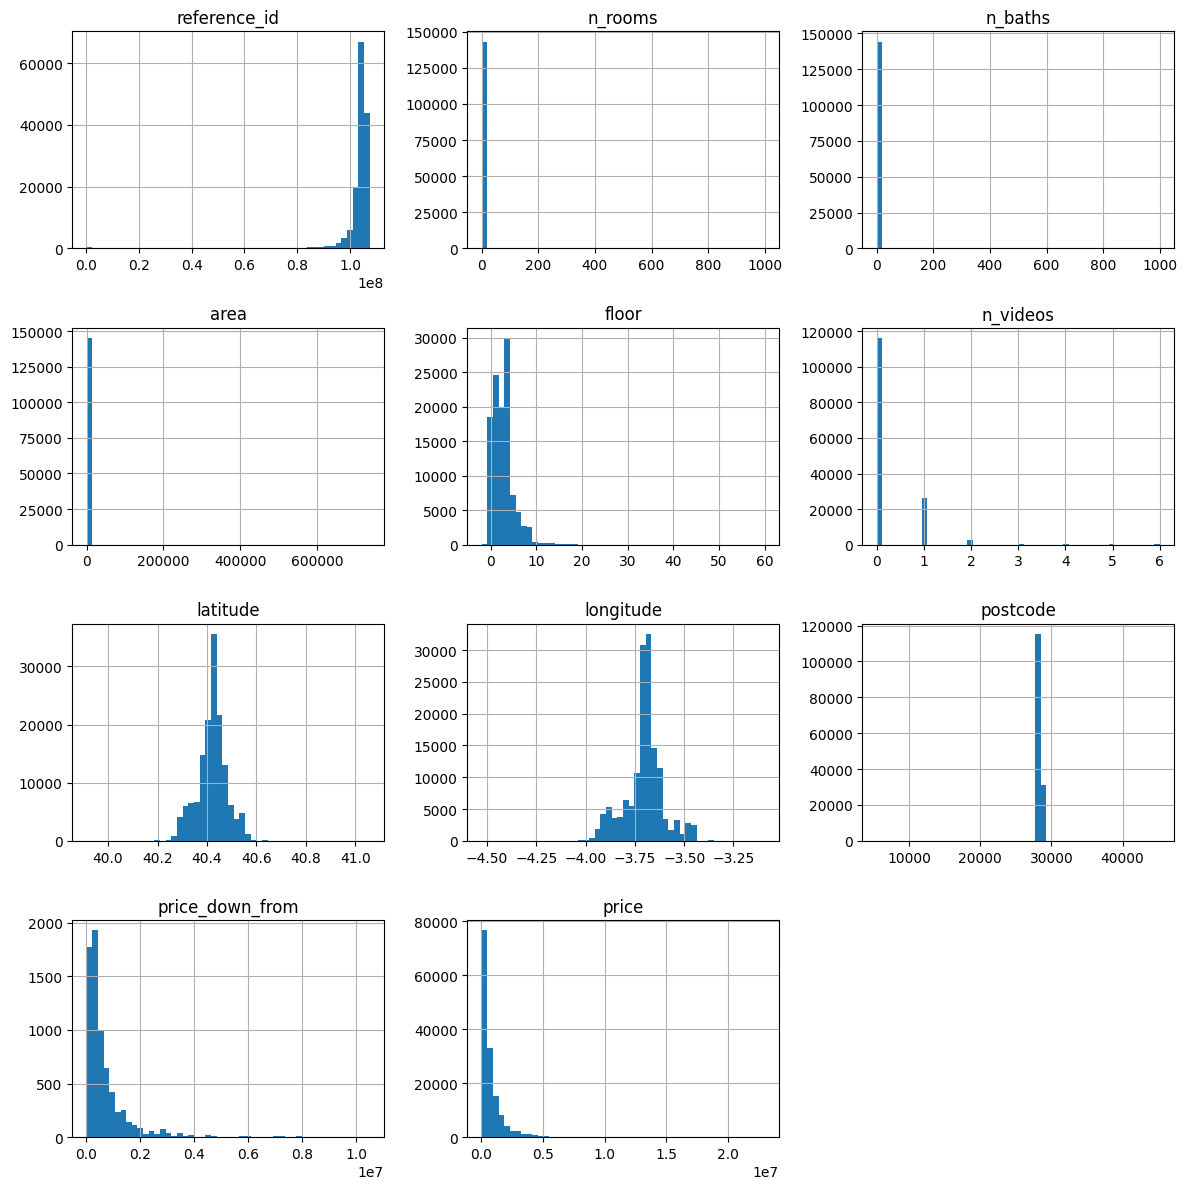

In [28]:
idealista_buy.hist(figsize=(12,12),bins = 50)
plt.tight_layout()
plt.show()

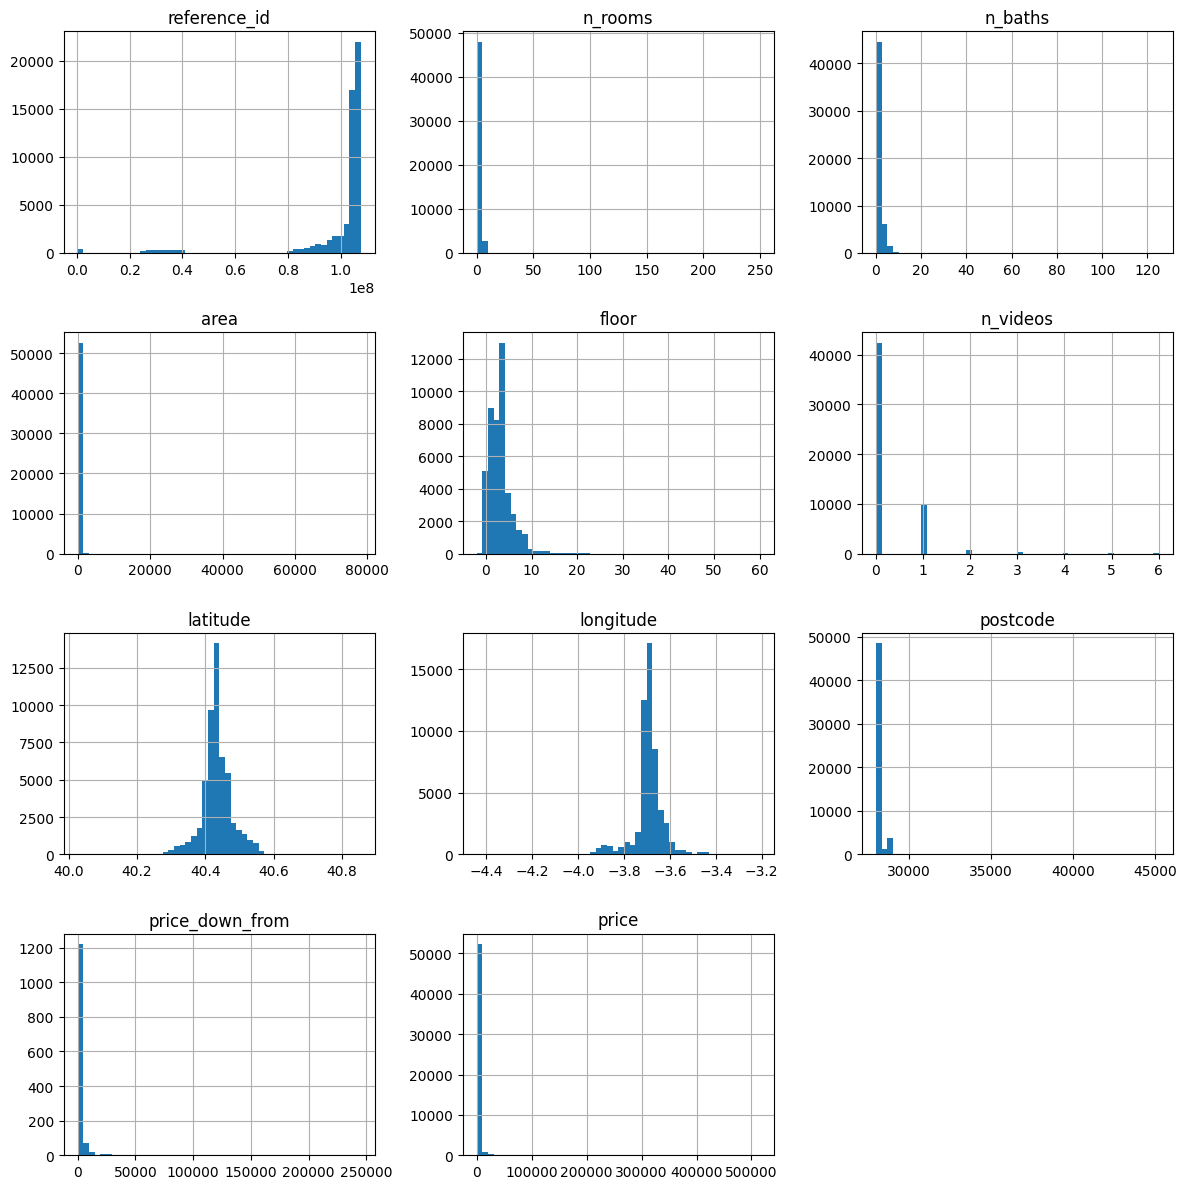

In [29]:
idealista_rent.hist(figsize=(12,12),bins = 50)
plt.tight_layout()
plt.show()

In [30]:
np.random.seed(314)

In [31]:
from sklearn.model_selection import train_test_split

rent_train_set, rent_test_set = train_test_split(idealista_rent, test_size = 0.2, random_state = 314)
buy_train_set, buy_test_set = train_test_split(idealista_buy, test_size = 0.2, random_state = 314)

# Buy Data Set

## Discover and Visualize data

In [32]:
idealista_buy = buy_train_set.copy()

<Figure size 1200x1200 with 0 Axes>

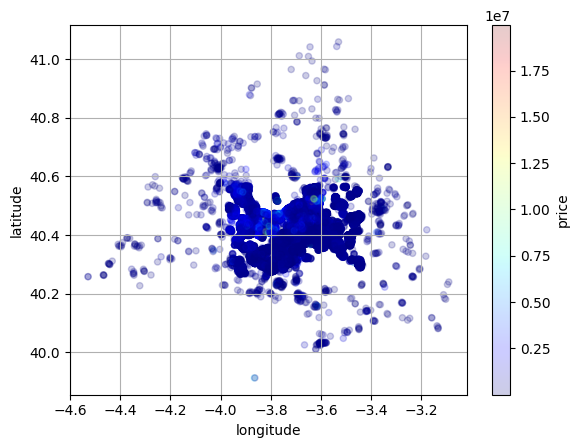

In [33]:
plt.figure(figsize=(12,12))
idealista_buy.plot(kind = 'scatter',x = 'longitude', y = 'latitude', grid = True, alpha = 0.2,
                   c = 'price', cmap = plt.get_cmap('jet'),colorbar = True,legend = True,sharex = False)
plt.show()


The price has an insanely high std, so we see most properties are in the center on Madrid, but we can´t identify the price because of the high std.

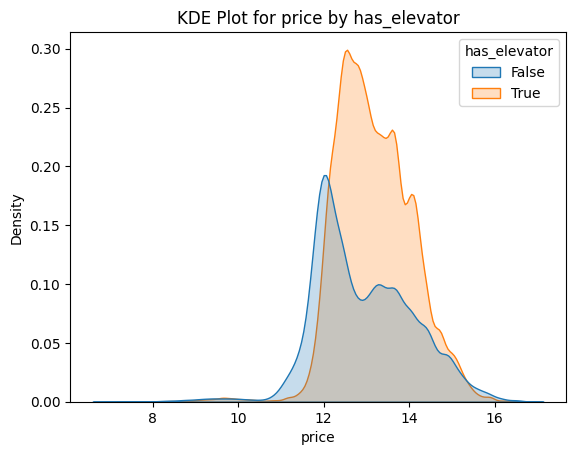

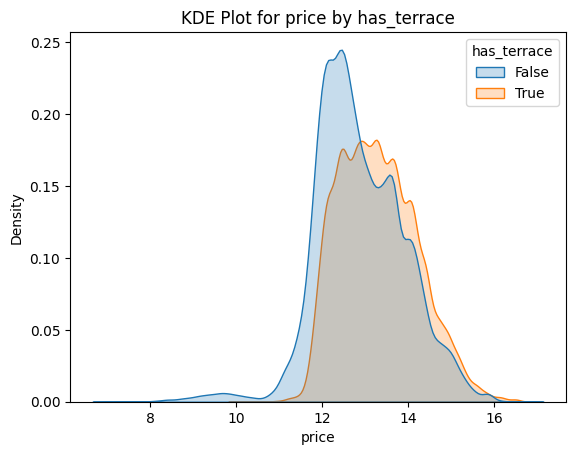

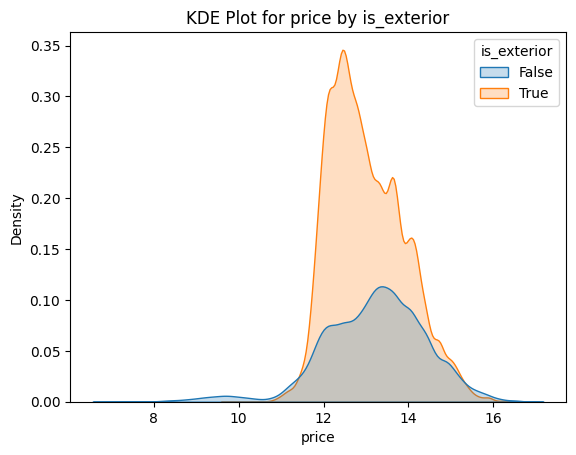

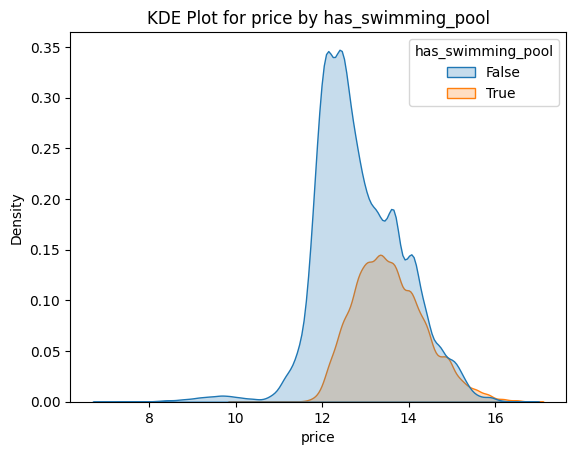

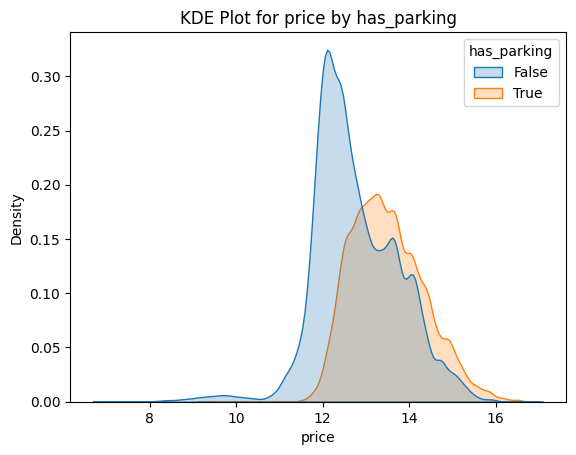

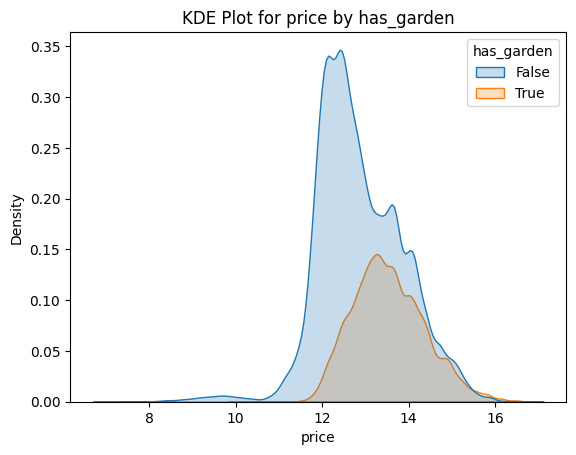

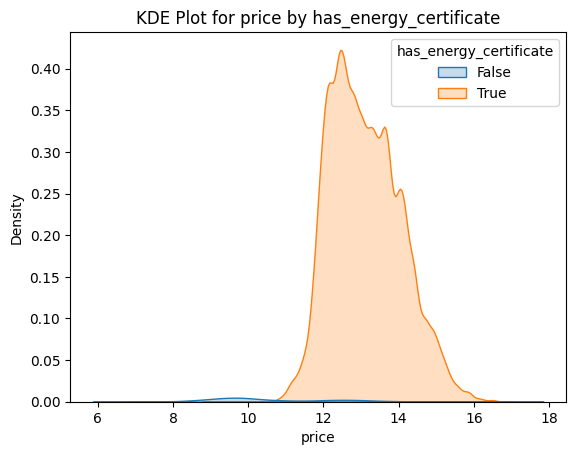

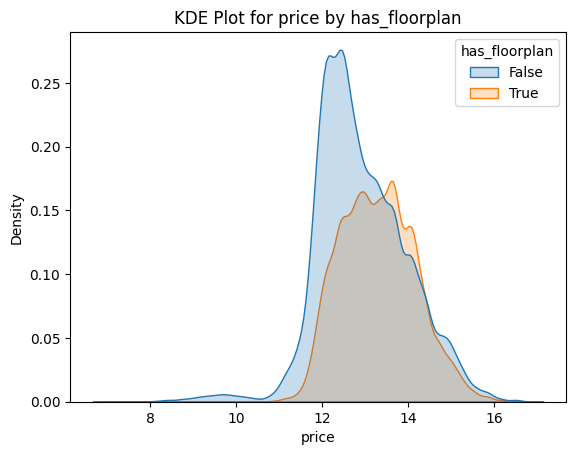

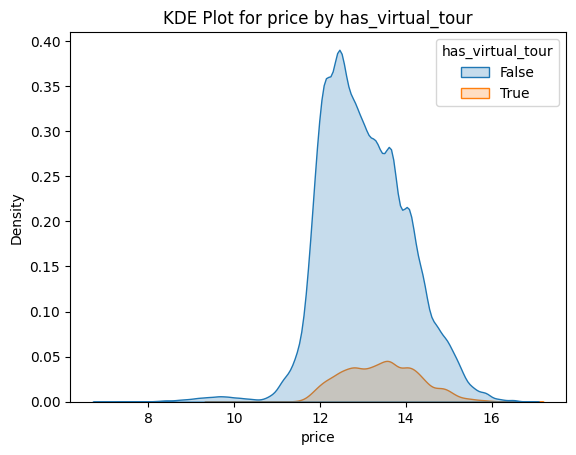

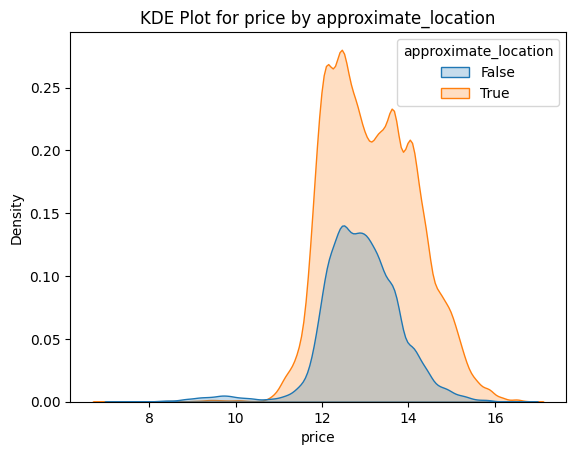

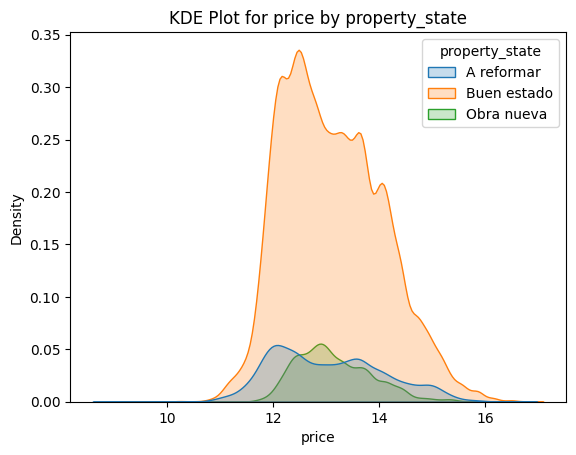

In [34]:
import seaborn as sns

df = idealista_buy.copy()
df['is_exterior'] = df['is_exterior'].astype(bool)

for i, feature in enumerate(df.select_dtypes(include='bool').columns):
    plt.figure(i)
    sns.kdeplot(data=df, x=np.log1p(df['price']), hue=feature, fill=True)
    plt.title(f"KDE Plot for price by {feature}")
    plt.show()

plt.figure(i+1)
sns.kdeplot(data=df, x=np.log1p(df['price']), hue=df['property_state'].astype('category'), fill=True)
plt.title(f"KDE Plot for price by property_state")
plt.show()

## Looking for correlations

In [35]:
corr_matrix = idealista_buy.corr(numeric_only= True)
corr_matrix['price'].sort_values(ascending = False)

price                     1.000000
price_down_from           0.988015
n_baths                   0.312674
has_parking               0.234560
n_rooms                   0.232212
latitude                  0.226913
has_swimming_pool         0.208133
has_garden                0.196877
floor                     0.167287
approximate_location      0.123752
has_terrace               0.123248
n_videos                  0.074653
has_floorplan             0.072413
has_virtual_tour          0.072179
area                      0.065362
has_energy_certificate    0.064616
has_elevator             -0.013725
reference_id             -0.027369
longitude                -0.066471
postcode                 -0.163636
Name: price, dtype: float64

We see some interesting features such as number of baths, if the property has parking and the number of rooms being the most correlated to the price.`price_down_from` isn´t taken into account as it is information we won´t have when given a new property and it has a lot of missing values.

/tmp/ipykernel_35461/2002962467.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corr_df['has_parking'] = corr_df['has_parking'].astype(int)


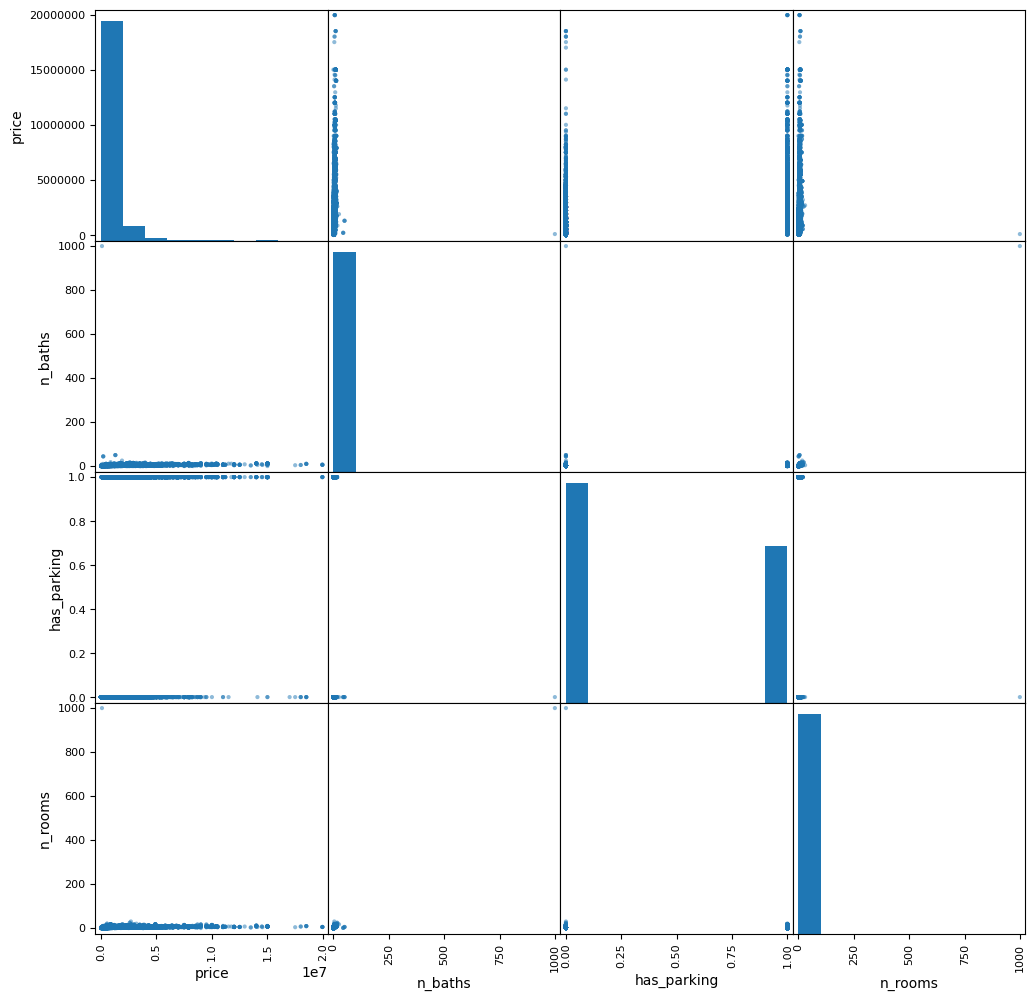

In [36]:
from pandas.plotting import scatter_matrix

features = ['price','n_baths', 'has_parking', 'n_rooms']
corr_df = idealista_buy[features]

corr_df['has_parking'] = corr_df['has_parking'].astype(int)
scatter_matrix(corr_df, figsize = (12,12))
plt.show()


## Feature combination

In [37]:
idealista_buy['rooms/area'] = idealista_buy['n_rooms'] / idealista_buy['area']

In [38]:
corr_matrix = idealista_buy.corr(numeric_only= True)
corr_matrix['price'].sort_values(ascending = False)

price                     1.000000
price_down_from           0.988015
n_baths                   0.312674
has_parking               0.234560
n_rooms                   0.232212
latitude                  0.226913
has_swimming_pool         0.208133
has_garden                0.196877
floor                     0.167287
approximate_location      0.123752
has_terrace               0.123248
n_videos                  0.074653
has_floorplan             0.072413
has_virtual_tour          0.072179
area                      0.065362
has_energy_certificate    0.064616
has_elevator             -0.013725
reference_id             -0.027369
longitude                -0.066471
rooms/area               -0.103111
postcode                 -0.163636
Name: price, dtype: float64

## Preparing data for Machine Learning Algorithms

In [39]:
idealista_buy = buy_train_set.drop('price',axis = 1)
idealista_buy_labels = buy_train_set['price'].copy()


### Data cleaning

In [40]:
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import FunctionTransformer
from sklearn import set_config

set_config(transform_output="pandas")  # para que los outputs sigan siendo DataFrames


In [41]:
def filtrar_madrid(X):

    return X[X['city'].str.lower() == 'madrid'].copy()

transformer_madrid = FunctionTransformer(filtrar_madrid)

def filtrar_vivendas(X):
    return X[X['property_type'].isin(['vivienda', 'viviendas'])]

filter_type = FunctionTransformer(filtrar_vivendas)


In [42]:
filtrado = make_pipeline(transformer_madrid,filter_type)

In [43]:
idealista_buy = filtrado.fit_transform(idealista_buy)

In [44]:
idealista_buy['city'].value_counts()

city
Madrid    39505
madrid    19733
MADRID    19566
Name: count, dtype: int64

In [45]:
idealista_buy['property_type'].value_counts()

property_type
vivienda     39436
viviendas    39368
Name: count, dtype: int64

In [46]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import make_pipeline

# Función que elimina filas que sean outliers sobre la matriz X
def eliminar_outliers(X):
    numeric_cols = X.select_dtypes(include=[np.number]).columns
    iso = IsolationForest(random_state=314)
    pred = iso.fit_predict(X[numeric_cols])
    return X[pred == 1]

# Convertir la función a un transformer para poder integrarla en el pipeline
filtrar_outliers = FunctionTransformer(eliminar_outliers)


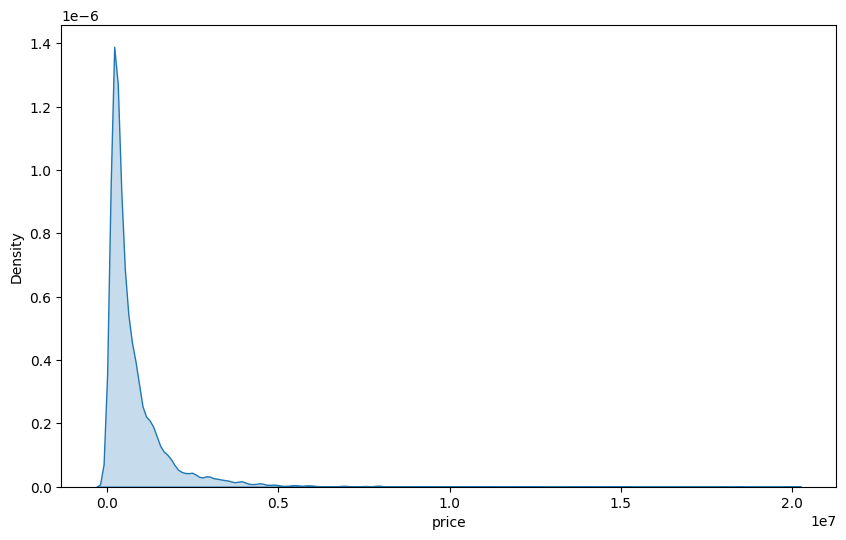

In [47]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.kdeplot(idealista_buy_labels,fill = True)
plt.show()

### Pipelines

In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn import set_config

set_config(display='diagram')

In [49]:
# Setting up the data using pipelines

from sklearn.preprocessing import OneHotEncoder

def log_transformer(X):
    return np.log1p(X)

def make_bool(X):
  return X.astype(float)

log_transformer = FunctionTransformer(log_transformer,inverse_func=np.expm1)

boolean_columns = [
    'has_elevator',
    'has_terrace',
    'is_exterior',
    'has_swimming_pool',
    'has_parking',
    'has_garden',
    'has_energy_certificate',
    'has_floorplan',
    'has_virtual_tour',
    'approximate_location'
]

log_features = ['n_rooms','n_baths','area','n_videos']

bool_transformer = FunctionTransformer(make_bool)

bool_pipeline = make_pipeline(
    bool_transformer,
    SimpleImputer(strategy="most_frequent"),
)

str_pipeline = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="UNKNOWN",missing_values=None),
    OneHotEncoder(handle_unknown='ignore',sparse_output=False)
)

log_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    log_transformer,
    StandardScaler()
)

num_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

preprocessing = ColumnTransformer([
    ('log',log_pipeline,log_features),
    ('str',str_pipeline,['energy_certificate_state','property_state']),
    ('bool',bool_pipeline,boolean_columns),
    ('num', num_pipeline, ['floor','latitude','longitude']),]
)

full_pipeline = make_pipeline(
    filtrado,
    preprocessing
)

idealista_buy_processed = full_pipeline.fit_transform(idealista_buy)
idealista_buy_labels = idealista_buy_labels[idealista_buy_processed.index]

## Modeling

In [50]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error

### Random Forest

In [51]:
from sklearn.ensemble import RandomForestRegressor

# Envolvemos el estimador con TransformedTargetRegressor indicando la función de transformación y su inversa
forest_reg = TransformedTargetRegressor(regressor=RandomForestRegressor(n_estimators=100, random_state=314),
                                               func=np.log1p,
                                               inverse_func=np.expm1)

# Ahora, al usar cross_val_score, le pasamos la variable objetivo original, sin transformar
'''forest_rmse = -cross_val_score(forest_reg,
                               idealista_buy_processed,
                               idealista_buy_labels,
                               scoring="mean_absolute_error",
                               cv=10)'''

# Rpint the MAE metric
#print("MAE cross-val:", forest_rmse.mean())

# Train the model
#forest_reg.fit(idealista_buy_processed,idealista_buy_labels)

'forest_rmse = -cross_val_score(forest_reg,\n                               idealista_buy_processed,\n                               idealista_buy_labels,\n                               scoring="mean_absolute_error",\n                               cv=10)'

In [52]:
'''# Predict
forest_pred=forest_reg.predict(idealista_buy_processed)

# Printing the mean % error
error_ratio = forest_pred.round(2) / idealista_buy_labels.round(2) -1

print(f"Media de error de {error_ratio.mean() * 100}%")

print(f"MAE train: {mean_absolute_error(idealista_buy_labels,forest_pred)}")

feature_importances = forest_reg.regressor_.feature_importances_

#Print feature importances
importances = sorted(zip(feature_importances, idealista_buy_processed.columns), reverse=True)

df_importances = pd.DataFrame(importances, columns=['importance', 'feature'])

df_importances'''

'# Predict\nforest_pred=forest_reg.predict(idealista_buy_processed)\n\n# Printing the mean % error\nerror_ratio = forest_pred.round(2) / idealista_buy_labels.round(2) -1\n\nprint(f"Media de error de {error_ratio.mean() * 100}%")\n\nprint(f"MAE train: {mean_absolute_error(idealista_buy_labels,forest_pred)}")\n\nfeature_importances = forest_reg.regressor_.feature_importances_\n\n#Print feature importances\nimportances = sorted(zip(feature_importances, idealista_buy_processed.columns), reverse=True)\n\ndf_importances = pd.DataFrame(importances, columns=[\'importance\', \'feature\'])\n\ndf_importances'

### MLP

In [53]:
from sklearn.neural_network import MLPRegressor

# Create estimator
mlp_reg = TransformedTargetRegressor(regressor=MLPRegressor(random_state=314,max_iter=1000),
                                               func=np.log1p,
                                               inverse_func=np.expm1)

# Measuring the error (RMSE) using cross-validation.
'''mlp_rmse = -cross_val_score(mlp_reg,
                               idealista_buy_processed,
                               idealista_buy_labels,
                               scoring="mean_absolute_error",
                               cv=10)'''

# Print mean MAE
#print("MAE cross-val:", mlp_rmse.mean())

# Train the model
#mlp_reg.fit(idealista_buy_processed,idealista_buy_labels)

'mlp_rmse = -cross_val_score(mlp_reg,\n                               idealista_buy_processed,\n                               idealista_buy_labels,\n                               scoring="mean_absolute_error",\n                               cv=10)'

In [54]:
'''# Predict
mlp_pred=mlp_reg.predict(idealista_buy_processed)

# Printing mean % error
error_ratio = mlp_pred.round(2) / idealista_buy_labels.round(2) -1

print(f"Media de error de {error_ratio.mean() * 100}%")


print(f"RMSE train: {mean_absolute_error(idealista_buy_labels,mlp_pred)}")'''

'# Predict\nmlp_pred=mlp_reg.predict(idealista_buy_processed)\n\n# Printing mean % error\nerror_ratio = mlp_pred.round(2) / idealista_buy_labels.round(2) -1\n\nprint(f"Media de error de {error_ratio.mean() * 100}%")\n\n\nprint(f"RMSE train: {mean_absolute_error(idealista_buy_labels,mlp_pred)}")'

### KNN

In [55]:
from sklearn.neighbors import KNeighborsRegressor

# Create estimator
knn_reg = TransformedTargetRegressor(
    regressor=KNeighborsRegressor(),
    func=np.log1p,
    inverse_func=np.expm1
)

# RMSE cross-val
'''knn_rmse = -cross_val_score(knn_reg,
                               idealista_buy_processed,
                               idealista_buy_labels,
                               scoring="mean_absolute_error",
                               cv=10)'''


# Print mean RMSE
#print("MAE cross-val:", knn_rmse.mean())

# Train the model
#knn_reg.fit(idealista_buy_processed,idealista_buy_labels)

'knn_rmse = -cross_val_score(knn_reg,\n                               idealista_buy_processed,\n                               idealista_buy_labels,\n                               scoring="mean_absolute_error",\n                               cv=10)'

In [56]:
'''# Predict
knn_pred=knn_reg.predict(idealista_buy_processed)

# Printing mean % error
error_ratio = knn_pred.round(2) / idealista_buy_labels.round(2) -1

print(f"Media de error de {error_ratio.mean() * 100}%")


print(f"MAE train: {mean_absolute_error(idealista_buy_labels,knn_pred)}")'''

'# Predict\nknn_pred=knn_reg.predict(idealista_buy_processed)\n\n# Printing mean % error\nerror_ratio = knn_pred.round(2) / idealista_buy_labels.round(2) -1\n\nprint(f"Media de error de {error_ratio.mean() * 100}%")\n\n\nprint(f"MAE train: {mean_absolute_error(idealista_buy_labels,knn_pred)}")'

### SVM rbf kernel

In [57]:
svm_train = idealista_buy_processed.sample(frac=0.4, random_state=314)
svm_labels = idealista_buy_labels.loc[svm_train.index]

In [58]:
svm_train.shape

(31522, 31)

In [59]:
from sklearn.svm import SVR

# Create estimator
svm_reg = TransformedTargetRegressor(
    regressor=SVR(),
    func=np.log1p,
    inverse_func=np.expm1
)

# RMSE cross-val
'''svm_rmse = -cross_val_score(svm_reg,
                               svm_train,
                               svm_labels,
                               scoring="mean_absolute_error",
                               cv=5)'''


# Print mean RMSE
#print("MAE cross-val:", svm_rmse.mean())

# Train the model
#svm_reg.fit(svm_train,svm_labels)

'svm_rmse = -cross_val_score(svm_reg,\n                               svm_train,\n                               svm_labels,\n                               scoring="mean_absolute_error",\n                               cv=5)'

In [60]:
'''# Predict
svm_pred=svm_reg.predict(idealista_buy_processed)

#Printing mean % error
error_ratio = svm_pred.round(2) / idealista_buy_labels.round(2) -1

print(f"Media de error de {error_ratio.mean() * 100}%")

print(f"RMSE train: {root_mean_squared_error(idealista_buy_labels,svm_pred)}")'''


'# Predict\nsvm_pred=svm_reg.predict(idealista_buy_processed)\n\n#Printing mean % error\nerror_ratio = svm_pred.round(2) / idealista_buy_labels.round(2) -1\n\nprint(f"Media de error de {error_ratio.mean() * 100}%")\n\nprint(f"RMSE train: {root_mean_squared_error(idealista_buy_labels,svm_pred)}")'

### Lasso regression

In [61]:
from sklearn.linear_model import Lasso
# Create estimator
lasso_reg = TransformedTargetRegressor(
    regressor=Lasso(),
    func=np.log1p,
    inverse_func=np.expm1
)
# RMSE cross-val
'''lasso_rmse = -cross_val_score(lasso_reg,
                               idealista_buy_processed,
                               idealista_buy_labels,
                               scoring="mean_absolute_error",
                               cv=10)'''
'''# Print mean RMSE
print("MAE cross-val:", lasso_rmse.mean())
# Train the model
lasso_reg.fit(idealista_buy_processed,idealista_buy_labels)'''

'# Print mean RMSE\nprint("MAE cross-val:", lasso_rmse.mean())\n# Train the model\nlasso_reg.fit(idealista_buy_processed,idealista_buy_labels)'

In [62]:
'''# Predict
lasso_pred=lasso_reg.predict(idealista_buy_processed)
# Printing mean % error
error_ratio = lasso_pred.round(2) / idealista_buy_labels.round(2) -1
print(f"Media de error de {error_ratio.mean() * 100}%")
print(f"RMSE train: {mean_absolute_error(idealista_buy_labels,lasso_pred)}")'''

'# Predict\nlasso_pred=lasso_reg.predict(idealista_buy_processed)\n# Printing mean % error\nerror_ratio = lasso_pred.round(2) / idealista_buy_labels.round(2) -1\nprint(f"Media de error de {error_ratio.mean() * 100}%")\nprint(f"RMSE train: {mean_absolute_error(idealista_buy_labels,lasso_pred)}")'

### SVM linear kernel

In [63]:
# Create estimator
svm_reg = TransformedTargetRegressor(
    regressor=SVR(kernel='linear'),
    func=np.log1p,
    inverse_func=np.expm1
)

# RMSE cross-val
'''svm_rmse = -cross_val_score(svm_reg,
                               svm_train,
                               svm_labels,
                               scoring="mean_absolute_error",
                               cv=5)'''


# Print mean RMSE
'''print("MAE cross-val:", svm_rmse.mean())

# Train the model
svm_reg.fit(svm_train,svm_labels)'''

'print("MAE cross-val:", svm_rmse.mean())\n\n# Train the model\nsvm_reg.fit(svm_train,svm_labels)'

In [64]:
'''# Predict
svm_pred=svm_reg.predict(idealista_buy_processed)

#Printing mean % error
error_ratio = svm_pred.round(2) / idealista_buy_labels.round(2) -1

print(f"Media de error de {error_ratio.mean() * 100}%")

print(f"RMSE train: {mean_absolute_error(idealista_buy_labels,svm_pred)}")
'''

'# Predict\nsvm_pred=svm_reg.predict(idealista_buy_processed)\n\n#Printing mean % error\nerror_ratio = svm_pred.round(2) / idealista_buy_labels.round(2) -1\n\nprint(f"Media de error de {error_ratio.mean() * 100}%")\n\nprint(f"RMSE train: {mean_absolute_error(idealista_buy_labels,svm_pred)}")\n'

## Model fine-tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error
from scipy.stats import uniform, loguniform, randint
from sklearn.metrics import cross_val_score

### SVM fine-tune

In [66]:
from scipy.stats import uniform, loguniform, randint

rndm_search = RandomizedSearchCV(
    estimator=svm_reg,
    param_distributions={
        'regressor__C': loguniform(0.1, 100),
        'regressor__kernel': ['linear', 'rbf', 'poly'],
        'regressor__degree': randint(1, 6),  
    },
    n_iter=10,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=314,
)

#rndm_search.fit(svm_train, svm_labels)

In [67]:
'''print("Best parameters:", rndm_search.best_params_)
print("Best score:", -rndm_search.best_score_)
print("Best estimator:", rndm_search.best_estimator_)
best_svm = rndm_search.best_estimator_
print(f"RMSE train: {root_mean_squared_error(idealista_buy_labels,best_svm.predict(idealista_buy_processed))}")
print(f"Media de error de {(best_svm.predict(idealista_buy_processed).round(2) / idealista_buy_labels.round(2) -1).mean() * 100}%")'''

'print("Best parameters:", rndm_search.best_params_)\nprint("Best score:", -rndm_search.best_score_)\nprint("Best estimator:", rndm_search.best_estimator_)\nbest_svm = rndm_search.best_estimator_\nprint(f"RMSE train: {root_mean_squared_error(idealista_buy_labels,best_svm.predict(idealista_buy_processed))}")\nprint(f"Media de error de {(best_svm.predict(idealista_buy_processed).round(2) / idealista_buy_labels.round(2) -1).mean() * 100}%")'

### Random Forest fine-tuning

In [68]:
forest_rndm = RandomizedSearchCV(
    estimator=forest_reg,
    param_distributions={
        'regressor__max_depth': randint(5, 30),
        'regressor__min_samples_split': randint(2, 20),
        'regressor__min_samples_leaf': randint(1, 20),
        'regressor__max_features': randint(4,30),
        'regressor__n_estimators': randint(80, 200),
    },
    n_iter=15,
    cv=5,
    scoring='mean_absolute_error',
    random_state=314,
    )

#forest_rndm.fit(idealista_buy_processed, idealista_buy_labels)

In [69]:
'''print("Best parameters:", forest_rndm.best_params_)
print("Best score:", -forest_rndm.best_score_)
print("Best estimator:", forest_rndm.best_estimator_)
best_forest = forest_rndm.best_estimator_
print(f"MAE train: {mean_absolute_error(idealista_buy_labels,best_forest.predict(idealista_buy_processed))}")
print(f"Media de error de {(best_forest.predict(idealista_buy_processed).round(2) / idealista_buy_labels.round(2) -1).mean() * 100}%")'''

'print("Best parameters:", forest_rndm.best_params_)\nprint("Best score:", -forest_rndm.best_score_)\nprint("Best estimator:", forest_rndm.best_estimator_)\nbest_forest = forest_rndm.best_estimator_\nprint(f"MAE train: {mean_absolute_error(idealista_buy_labels,best_forest.predict(idealista_buy_processed))}")\nprint(f"Media de error de {(best_forest.predict(idealista_buy_processed).round(2) / idealista_buy_labels.round(2) -1).mean() * 100}%")'

In [ ]:
final_random_forest = GridSearchCV(
    estimator=forest_reg,
    param_grid = {
        'regressor__max_depth': [21],
        'regressor__max_features': [11],
        'regressor__min_samples_leaf': [3],
        'regressor__min_samples_split': [9],
        'regressor__n_estimators': [160,180,200,220],
    },
    cv=5,
    scoring='neg_mean_absolute_error'
)

#final_random_forest.fit(idealista_buy_processed, idealista_buy_labels)

GridSearchCV(cv=5,
             estimator=TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                                  inverse_func=<ufunc 'expm1'>,
                                                  regressor=RandomForestRegressor(random_state=314)),
             param_grid={'regressor__max_depth': [21],
                         'regressor__max_features': [11],
                         'regressor__min_samples_leaf': [3],
                         'regressor__min_samples_split': [9],
                         'regressor__n_estimators': [160, 180, 200, 220]},
             scoring='neg_mean_absolute_error')

In [ ]:
print("Best parameters:", final_random_forest.best_params_)
print("Best score:", -final_random_forest.best_score_)
print("Best estimator:", final_random_forest.best_estimator_)
best_forest = final_random_forest.best_estimator_
print(f"MAE train: {mean_absolute_error(idealista_buy_labels,best_forest.predict(idealista_buy_processed))}")
mpe_cross_val = cross_val_score(best_forest,idealista_buy_processed,idealista_buy_labels,scoring='neg_mean_absolute_percentage_error',cv=5)
print(f"MPE cross-val: {mpe_cross_val.mean() * 100}%")

Best parameters: {'regressor__max_depth': 21, 'regressor__max_features': 11, 'regressor__min_samples_leaf': 3, 'regressor__min_samples_split': 9, 'regressor__n_estimators': 220}
Best score: 80315.1460228324
Best estimator: TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=RandomForestRegressor(max_depth=21,
                                                           max_features=11,
                                                           min_samples_leaf=3,
                                                           min_samples_split=9,
                                                           n_estimators=220,
                                                           random_state=314))
MAE train: 52517.546810933774
Media de error de 0.5938192496357823%
MPE cross-val: -10.378387318910894%


In [73]:
feature_importances = best_forest.regressor_.feature_importances_

importances_df = pd.DataFrame({'Feature': idealista_buy_processed.columns,    'Importance': feature_importances})

# Ordenar el DataFrame por importancia descendente
importances_df = importances_df.sort_values(by='Importance', ascending=False)

importances_df

,Feature,Importance
2,log__area,0.371933
1,log__n_baths,0.251004
29,num__latitude,0.170978
30,num__longitude,0.064487
0,log__n_rooms,0.050250
18,bool__has_elevator,0.034381
28,num__floor,0.012556
22,bool__has_parking,0.011474
21,bool__has_swimming_pool,0.006447
20,bool__is_exterior,0.003253


### MLP fine-tuning

In [74]:
rndm_mlp = RandomizedSearchCV(
    estimator=mlp_reg,
    param_distributions={
        'regressor__hidden_layer_sizes': [(300,200,100), (200, 100,100), (100, 100, 100), (100, 100,100,100,100)],
        'regressor__activation': ['relu', 'tanh', 'logistic'],
        'regressor__solver': ['adam', 'sgd'],
        'regressor__alpha': loguniform(1e-5, 1e-1),
        'regressor__learning_rate': ['constant', 'adaptive'],
    },
    n_iter=25,
    cv=5,
    scoring='neg_mean_absolute_error',
    random_state=314,
)
'''rndm_mlp.fit(idealista_buy_processed, idealista_buy_labels)'''

'rndm_mlp.fit(idealista_buy_processed, idealista_buy_labels)'

In [75]:
'''print("Best parameters:", rndm_mlp.best_params_)
print("Best score:", -rndm_mlp.best_score_)
print("Best estimator:", rndm_mlp.best_estimator_)
best_mlp = rndm_mlp.best_estimator_
print(f"MAE train: {mean_absolute_error(idealista_buy_labels,best_mlp.predict(idealista_buy_processed))}")'''

'print("Best parameters:", rndm_mlp.best_params_)\nprint("Best score:", -rndm_mlp.best_score_)\nprint("Best estimator:", rndm_mlp.best_estimator_)\nbest_mlp = rndm_mlp.best_estimator_\nprint(f"MAE train: {mean_absolute_error(idealista_buy_labels,best_mlp.predict(idealista_buy_processed))}")'

In [ ]:
mlp_final_model = GridSearchCV(
    estimator=mlp_reg,
    param_grid = {
        'regressor__activation': ['tanh'],
        'regressor__alpha': [1.337259236559212e-05],
        'regressor__hidden_layer_sizes': [(100, 100, 100, 100, 100),(100,100,100,100,100,100),(100,100,100,100,100,100,100)],
        'regressor__max_iter': [1000],
        'regressor__random_state': [314],
        'regressor__solver': ['adam'],
        'regressor__learning_rate': ['constant'],
    },
    cv=5,
    scoring='neg_mean_absolute_error'
)

#mlp_final_model.fit(idealista_buy_processed, idealista_buy_labels)

GridSearchCV(cv=5,
             estimator=TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                                  inverse_func=<ufunc 'expm1'>,
                                                  regressor=MLPRegressor(max_iter=1000,
                                                                         random_state=314)),
             param_grid={'regressor__activation': ['tanh'],
                         'regressor__alpha': [1.337259236559212e-05],
                         'regressor__hidden_layer_sizes': [(100, 100, 100, 100,
                                                            100),
                                                           (100, 100, 100, 100,
                                                            100, 100),
                                                           (100, 100, 100, 100,
                                                            100, 100, 100)],
                         'regressor__learning_rate': ['constant'],
                         'regressor__max_iter': [1000],
                         'regressor__random_state': [314],
                         'regressor__solver': ['adam']},
             scoring='neg_mean_absolute_error')

In [90]:
print("Best parameters:", mlp_final_model.best_params_)
print("Best score:", -mlp_final_model.best_score_)
print("Best estimator:", mlp_final_model.best_estimator_)
best_mlp_final = mlp_final_model.best_estimator_
print(f"MAE train: {mean_absolute_error(idealista_buy_labels,best_mlp_final.predict(idealista_buy_processed))}")
mpe_cross_val = cross_val_score(best_mlp_final,idealista_buy_processed,idealista_buy_labels,scoring='neg_mean_absolute_percentage_error',cv=5)
print(f"MPE cross-val: {mpe_cross_val.mean() * 100}%")

Best parameters: {'regressor__activation': 'tanh', 'regressor__alpha': 1.337259236559212e-05, 'regressor__hidden_layer_sizes': (100, 100, 100, 100, 100), 'regressor__learning_rate': 'constant', 'regressor__max_iter': 1000, 'regressor__random_state': 314, 'regressor__solver': 'adam'}
Best score: 84943.50566627008
Best estimator: TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=MLPRegressor(activation='tanh',
                                                  alpha=1.337259236559212e-05,
                                                  hidden_layer_sizes=(100, 100,
                                                                      100, 100,
                                                                      100),
                                                  max_iter=1000,
                                                  random_state=314))
MAE train: 59515.49592822748
MPE cross-val: -11.203203181794933%


### KNN fine-tune

In [ ]:
knn_rndm = RandomizedSearchCV(
    estimator=knn_reg,
    param_distributions={
        'regressor__n_neighbors': randint(3, 15),
        'regressor__weights': ['distance'],
        'regressor__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
        'regressor__leaf_size': randint(1, 15),
        'regressor__p': [1, 2],
    },
    n_iter=15,
    cv=5,
    scoring='neg_mean_absolute_error',
    random_state=314,
)

#knn_rndm.fit(idealista_buy_processed, idealista_buy_labels)

RandomizedSearchCV(cv=5,
                   estimator=TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                                        inverse_func=<ufunc 'expm1'>,
                                                        regressor=KNeighborsRegressor()),
                   n_iter=15,
                   param_distributions={'regressor__algorithm': ['auto',
                                                                 'ball_tree',
                                                                 'kd_tree',
                                                                 'brute'],
                                        'regressor__leaf_size': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d5b3c17f950>,
                                        'regressor__n_neighbors': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d5b3c7b3f50>,
                                        'regressor__p': [1, 2],
                                        'regressor__weights': ['distance']},
                   random_state=314, scoring='neg_mean_absolute_error')

In [91]:
print("Best parameters:", knn_rndm.best_params_)
print("Best score:", -knn_rndm.best_score_)
print("Best estimator:", knn_rndm.best_estimator_)
best_knn = knn_rndm.best_estimator_
print(f"MAE train: {mean_absolute_error(idealista_buy_labels,best_knn.predict(idealista_buy_processed))}")
mpe_cross_val = cross_val_score(best_knn,idealista_buy_processed,idealista_buy_labels,scoring='neg_mean_absolute_percentage_error',cv=5)
print(f"MPE cross-val: {mpe_cross_val.mean() * 100}%")

Best parameters: {'regressor__algorithm': 'ball_tree', 'regressor__leaf_size': 7, 'regressor__n_neighbors': 14, 'regressor__p': 1, 'regressor__weights': 'distance'}
Best score: 58770.945956745636
Best estimator: TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=KNeighborsRegressor(algorithm='ball_tree',
                                                         leaf_size=7,
                                                         n_neighbors=14, p=1,
                                                         weights='distance'))
MAE train: 5313.41597879975
MPE cross-val: -8.355792848890612%


In [ ]:
final_knn = best_knn

We save the best models

In [95]:
import joblib
import os

# Create the directory if it doesn't exist
os.makedirs('./models', exist_ok=True)


joblib.dump(final_knn, './models/final_knn.pkl')
joblib.dump(best_forest, './models/final_forest.pkl')
joblib.dump(best_mlp_final, './models/final_mlp.pkl')

['./models/final_mlp.pkl']

## Model selection

After searching the best hyperparameters for the 3 most interesting models (**MLP**,**KNN** and **RandomForest**), we will choose knn as it is gets the best MAE and MAPE, the performance metrics we chose.

In [ ]:
final_model = final_knn

#joblib.dump(final_model,'./models/final_model.pkl')

['./models/final_model.pkl']

Let's see how it performs in the test dataset.

In [105]:
from sklearn.metrics import mean_absolute_percentage_error

test = buy_test_set.copy()

test_labels = buy_test_set['price']

test_processed = full_pipeline.transform(test)
test_labels_processed = test_labels[test_processed.index]

#test_pred = final_model.predict(test_processed)

MAE = mean_absolute_error(test_labels_processed,test_pred)
MAPE = mean_absolute_percentage_error(test_labels_processed,test_pred)
RMSE = root_mean_squared_error(test_labels_processed,test_pred)

print(f"MAE on test set: {MAE}")
print(f"MAPE on test set: {MAPE*100}")
print(f"'RMSE on test set: {RMSE}")

MAE on test set: 48852.313770793044
MAPE on test set: 6.978428738721014
'RMSE on test set: 250104.5597186152


We see the final results are even better than those we got in the cross-validation.

To sum up, the area and the number of bathrooms is the number one predictor of the housing price. Also we saw the properties at the north tend to be a little more expensive.